# 04 모델 학습·검증·평가

Z-score(표준점수), Isolation Forest(IF), Local Outlier Factor(LOF)를 동일 A16 기준에서 비교한다.

## 실행 준비

In [1]:
from pathlib import Path
import sys
sys.dont_write_bytecode = True
working_dir = Path.cwd().resolve()
root = working_dir if (working_dir/'src'/'paths.py').is_file() else working_dir.parent
sys.path.insert(0,str(root/'src'))
from IPython.display import display, Image


## 고정된 기간 분할

3~4월 자료 중 이후 고장 기록까지 확인해 정상 후보로 분류한 주기로 데이터의 척도를 맞추고 모델을 학습한다. 5~6월 자료에서는 고장 사건 9건 중 최소 7건을 미리 알리는 설정을 찾는다. 이 조건을 만족하는 설정 중 정상 구간에서 잘못 보내는 알림이 가장 적은 것을 선택한다. 오탐 알림 수가 같으면 탐지한 사건 수, 경보 선행시간의 중앙값, 임곗값 순으로 비교한다. LOF의 이웃 수까지 비교한 결과가 같으면 더 적은 이웃을 사용하는 설정을 선택한다.
- IF는 나무 300개를 사용하고, 각 나무를 만들 때 학습 자료 256개를 뽑는다. 같은 조건에서 결과를 재현하도록 난수 설정값은 42로 고정한다
- LOF는 주변의 비슷한 자료를 몇 개까지 비교할지 10·20·35·50·100개로 바꿔가며 확인한다. 학습에 쓰지 않은 새 자료도 판정할 수 있도록 설정한다

검증 자료에서 나온 서로 다른 점수들을 기준값 후보로 사용하며, 여기에는 평가에서 제외한 구간의 점수도 포함한다. 이상 점수가 기준값보다 클 때만 이상으로 판정하고, 같을 때는 이상으로 판정하지 않는다.

In [2]:
from preprocess import load_cycles, load_splits, load_episodes
from modeling import fit_model_grid, evaluate_selected, target_sensitivity, persist_model_outputs, output_paths
f=load_cycles()
splits=load_splits(f)
episodes=load_episodes()
train=f.loc[splits.train].reset_index(drop=True)
vf=f.loc[splits.validation].reset_index(drop=True)
tf=f.loc[splits.july].reset_index(drop=True)
ve=episodes.loc[episodes.start.ge('2020-05-01')&episodes.start.lt('2020-07-01')]
te=episodes.loc[episodes.start.ge('2020-07-01')&episodes.start.lt('2020-08-01')]
fit=fit_model_grid(train,vf,ve)
display(fit['candidates'][['id','feasible','threshold','events_detected','false_alerts']])
display(fit['selected'][['method','id','threshold','events_detected','false_alerts']])

,id,feasible,threshold,events_detected,false_alerts
0,ZScore,True,1.447497,7.0,164.0
1,IF,True,0.535155,7.0,36.0
2,LOF_k10,True,2.148892,7.0,57.0
3,LOF_k20,True,2.015209,7.0,57.0
4,LOF_k35,True,1.831420,7.0,60.0
5,LOF_k50,True,1.649481,7.0,67.0
6,LOF_k100,True,1.474730,7.0,64.0


,method,id,threshold,events_detected,false_alerts
0,ZScore,ZScore,1.447497,7.0,164.0
1,IF,IF,0.535155,7.0,36.0
2,LOF,LOF_k20,2.015209,7.0,57.0


## 선택한 모델과 기준으로 7월 자료 평가

5~6월 검증에서 모델과 임곗값을 정한 뒤, 그 설정을 그대로 사용해 7월 자료의 이상 점수를 계산한다.
경보가 언제 나왔을지 확인하기 위해 모든 점수를 시간순으로 살펴본다. 경보가 한 번 발생하면 이후 1시간 동안은 추가 경보를 보내지 않는 규칙을 적용한다.
평가를 시작할 때나 센서 기록이 끊겨 새로운 구간으로 넘어갈 때는 이전 경보의 대기시간을 초기화한다.

In [3]:
evaluation=evaluate_selected(fit,vf,tf,ve,te)
display(evaluation['metrics'].round(5))
bundle=persist_model_outputs(fit,evaluation)

,period,method,config,threshold,validation_feasible,events_detected,events_total,events_covered,event_recall,false_alerts,...,excluded_alerts,notification_precision,median_lead_hours,tp,fp,fn,tn,precision,recall,f1
0,validation,ZScore,ZScore,1.44750,True,7,9,9,0.77778,164,...,7,0.19212,23.50222,87,308,347,1906,0.22025,0.20046,0.20989
1,validation,IF,IF,0.53516,True,7,9,9,0.77778,36,...,6,0.33333,18.37722,26,52,408,2162,0.33333,0.05991,0.10156
2,validation,LOF,LOF_k20,2.01521,True,7,9,9,0.77778,57,...,6,0.20833,21.81167,16,70,418,2144,0.18605,0.03687,0.06154
3,July,ZScore,ZScore,1.44750,True,2,3,2,0.66667,134,...,11,0.16770,19.09417,144,230,38,1433,0.38503,0.79121,0.51799
4,July,IF,IF,0.53516,True,2,3,2,0.66667,35,...,4,0.36364,14.54792,118,52,64,1611,0.69412,0.64835,0.67045
5,July,LOF,LOF_k20,2.01521,True,0,3,2,0.00000,29,...,5,0.00000,NaN,0,34,182,1629,0.00000,0.00000,0.00000


## 고장 탐지 목표를 7건·8건·9건으로 바꿔 비교

검증 자료의 고장 사건 9건 중 최소 몇 건을 탐지할지 목표를 7건, 8건, 9건으로 바꿔가며 결과를 비교한다.
이미 학습한 모델과 계산된 검증 점수를 그대로 사용하고, 비교할 설정과 결과가 같을 때의 선택 기준도 유지한다. 각 목표에서 어떤 모델과 임곗값이 선택되는지 확인한다.

In [4]:
sensitivity=target_sensitivity(fit)
display(sensitivity['targets'])
display(sensitivity['replays'][['target','method','independent_replay_matches']])
from plot_models import plot_model_evaluation, plot_target_sensitivity
plot_model_evaluation(fit['selected'],fit['curves'],evaluation['metrics'])
plot_target_sensitivity(sensitivity['targets'])

,target,method,spec,k,feasible,threshold,events_detected,events_total,events_covered,event_recall,...,excluded_alerts,notification_precision,median_lead_hours,tn,fp,fn,tp,precision,recall,f1
0,7,ZScore,ZScore,0,True,1.447497,7.0,9.0,9.0,0.777778,...,7.0,0.192118,23.502222,1906.0,308.0,347.0,87.0,0.220253,0.200461,0.209891
1,7,IF,IF,0,True,0.535155,7.0,9.0,9.0,0.777778,...,6.0,0.333333,18.377222,2162.0,52.0,408.0,26.0,0.333333,0.059908,0.101562
2,7,LOF,LOF_k20,20,True,2.015209,7.0,9.0,9.0,0.777778,...,6.0,0.208333,21.811667,2144.0,70.0,418.0,16.0,0.186047,0.036866,0.061538
3,8,ZScore,ZScore,0,True,1.316338,8.0,9.0,9.0,0.888889,...,8.0,0.194444,23.157361,1731.0,483.0,283.0,151.0,0.238170,0.347926,0.282772
4,8,IF,IF,0,True,0.500857,8.0,9.0,9.0,0.888889,...,7.0,0.200000,23.407083,1933.0,281.0,352.0,82.0,0.225895,0.188940,0.205772
5,8,LOF,LOF_k10,10,True,2.088710,8.0,9.0,9.0,0.888889,...,6.0,0.164384,20.085139,2150.0,64.0,422.0,12.0,0.157895,0.027650,0.047059
6,9,ZScore,ZScore,0,True,1.248762,9.0,9.0,9.0,1.000000,...,9.0,0.198300,19.468611,1597.0,617.0,220.0,214.0,0.257521,0.493088,0.338340
7,9,IF,IF,0,True,0.475924,9.0,9.0,9.0,1.000000,...,9.0,0.218121,23.502222,1699.0,515.0,250.0,184.0,0.263233,0.423963,0.324801
8,9,LOF,LOF_k50,50,True,1.330697,9.0,9.0,9.0,1.000000,...,6.0,0.153846,21.661111,2050.0,164.0,405.0,29.0,0.150259,0.066820,0.092504


,target,method,independent_replay_matches
0,7,ZScore,True
1,7,IF,True
2,7,LOF,True
3,8,ZScore,True
4,8,IF,True
5,8,LOF,True
6,9,ZScore,True
7,9,IF,True
8,9,LOF,True


## 검증 선택과 7월 주기 지표

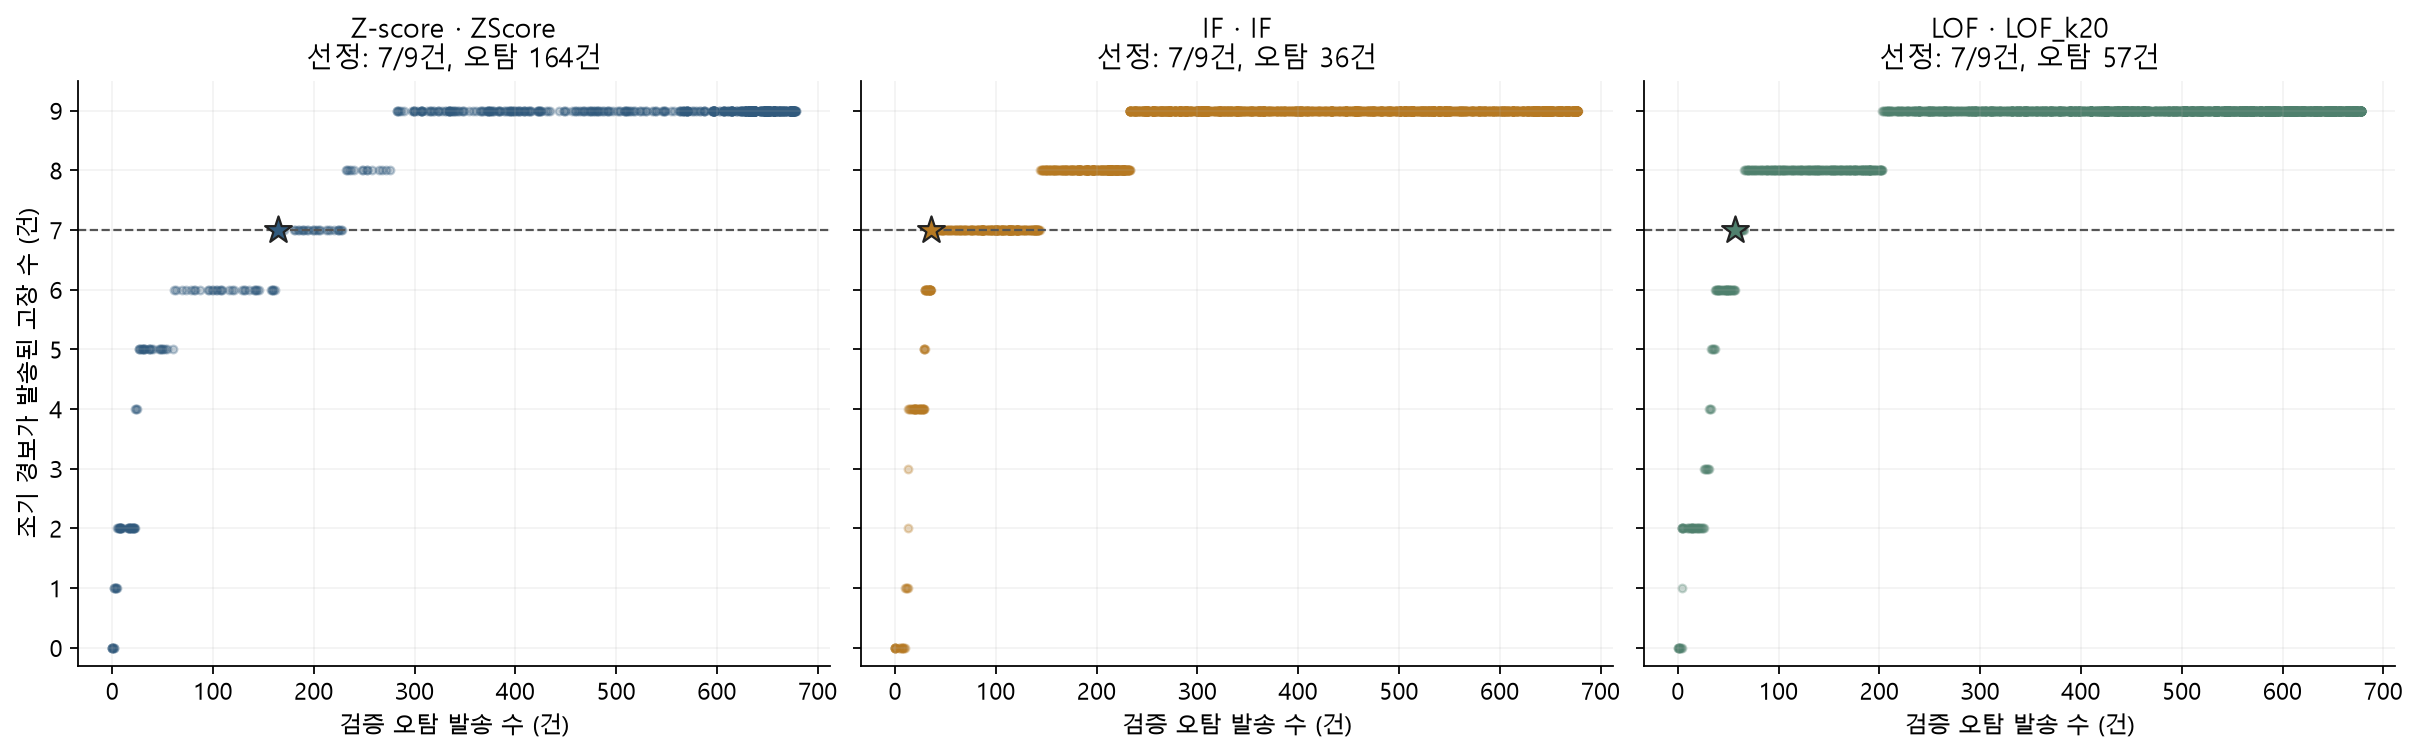

In [5]:
display(Image(filename=str(output_paths()['figure04'])))

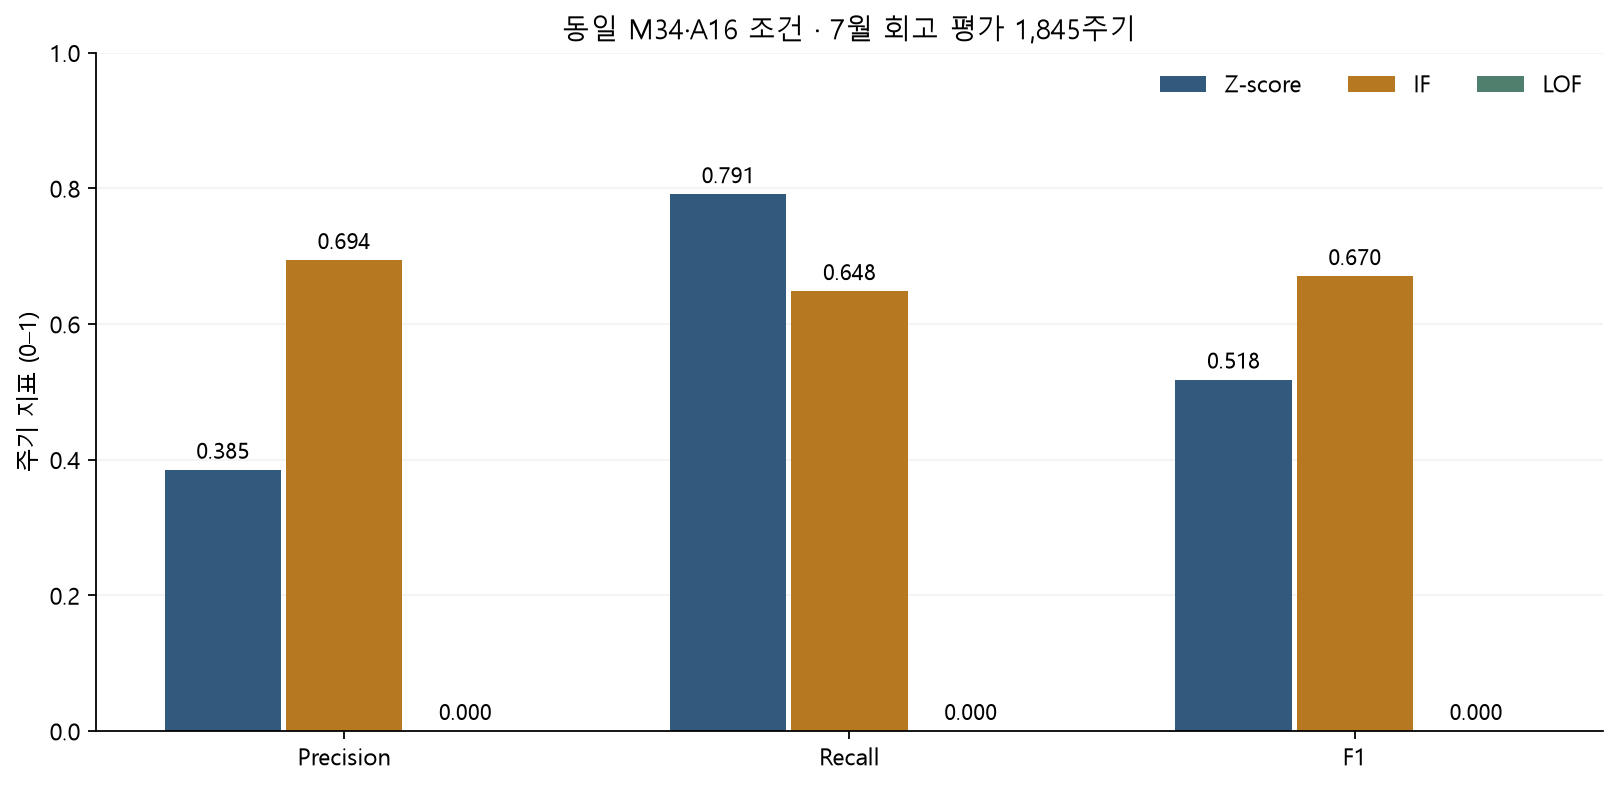

In [6]:
display(Image(filename=str(output_paths()['figure05'])))

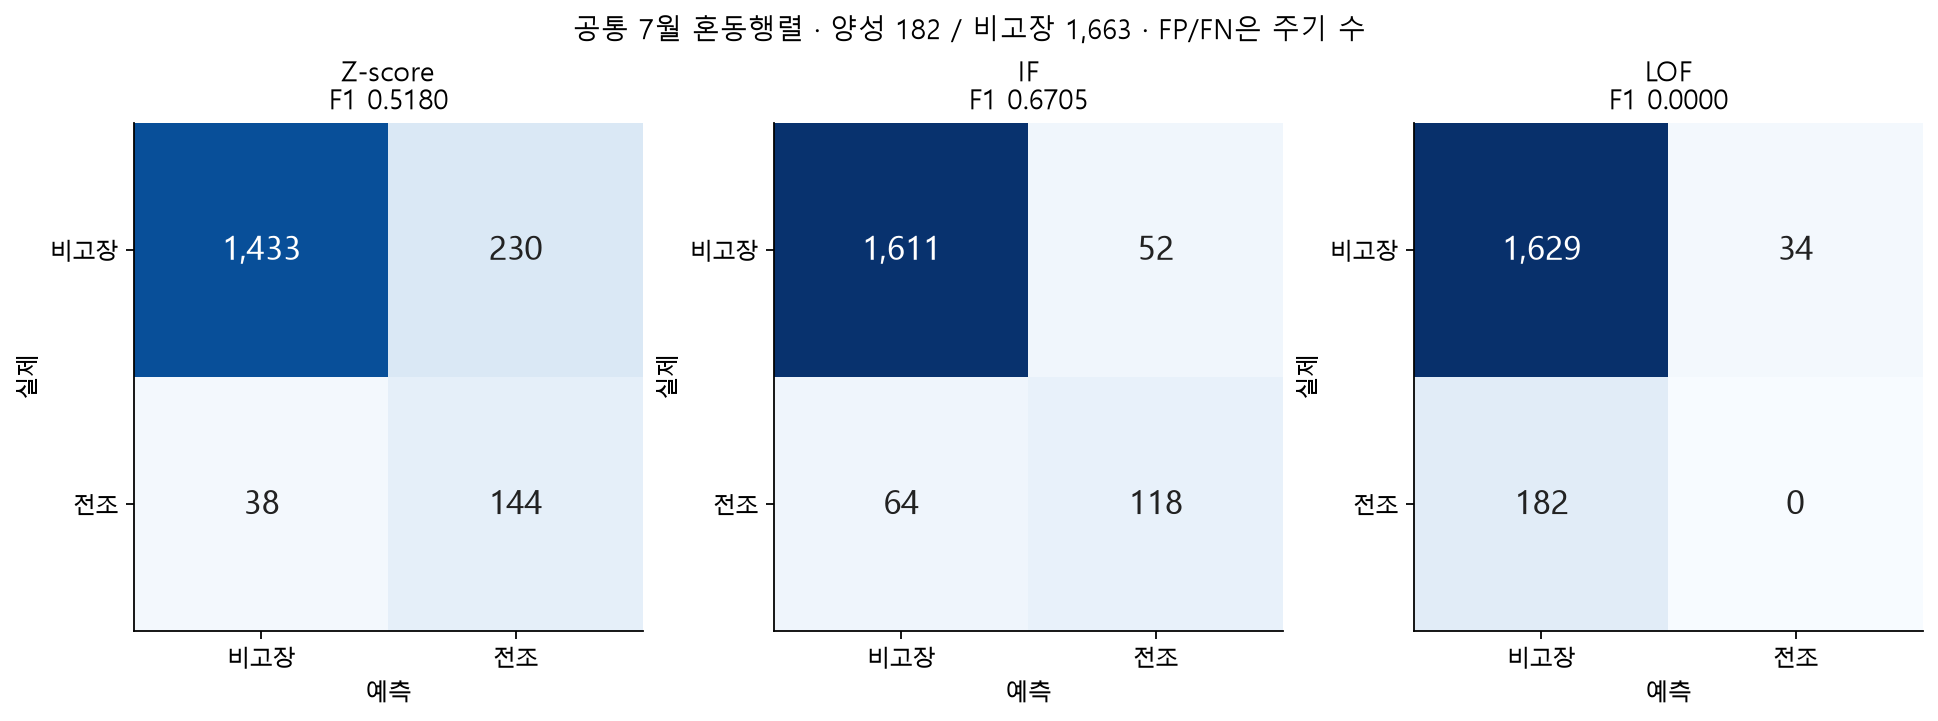

In [7]:
display(Image(filename=str(output_paths()['figure06'])))

## 검증 목표별 최소 오탐

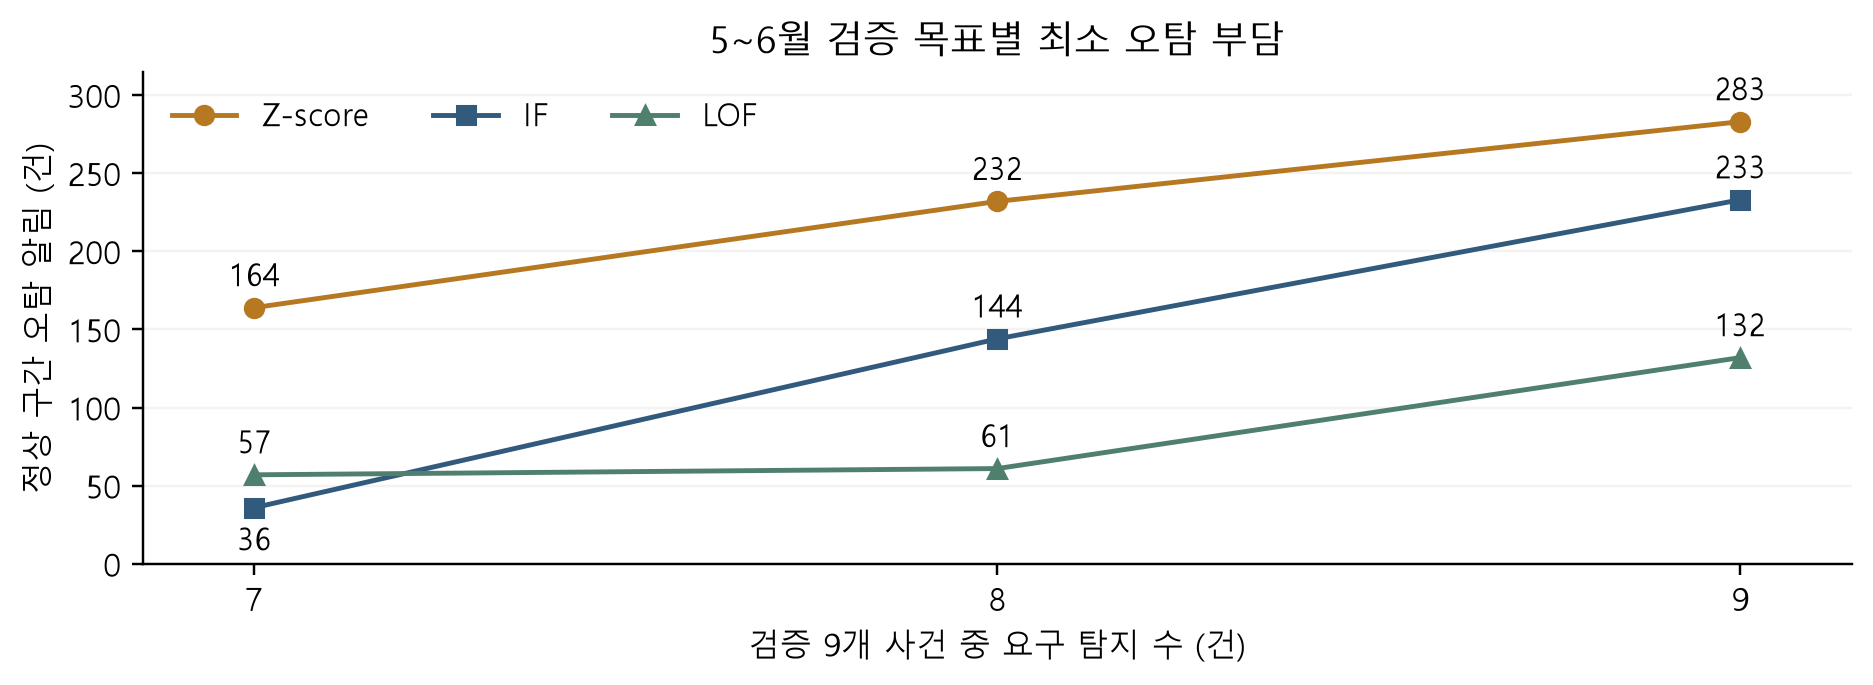

In [8]:
display(Image(filename=str(output_paths()['figure13'])))